<h2>Correlation and Simple Linear Regression </h2>

For the purpose of running linear regression to predict the charges, which is our business objective here, we would try to find related variable that may directly influence a medical insurance charges. One inherently feature is bmi as bmi is widely considered as a general health prediction (ie: The person with higher bmi then to be less healthy, therefore health complication of that person may increase with his/her bmi, thus driving the charges higher ). Therefore, for the purpose of this simple linear regression, we pick 2 features that is <b>bmi</b> and <b>charges</b>

In [38]:
from pathlib import Path
import pandas as pd
import numpy as np
def get_clean_csv():
    clean_csv_path = Path("datasets/medical_insurance/clean_insurance_data.csv")
    return pd.read_csv(clean_csv_path)
    
insurance = get_clean_csv()

In [39]:
from scipy import stats
bmi_data = insurance['bmi']
charges_data = insurance['charges']

linear_regression = stats.linregress(x = bmi_data, y = charges_data)
pearson_correlation = linear_regression.rvalue
b1 = linear_regression.slope  
b0 = linear_regression.intercept
print(f"Pearson correlation between bmi and charges: {pearson_correlation:.4f}")
print(f"The linear regression model equation: y = {b1:.4f}X + {b0:.4f}")

Pearson correlation between bmi and charges: 0.1943
The linear regression model equation: y = 395.2945X + 1098.2106


<h3>Correlation</h3>

<ul> We can see from the result of linear regression that we ran, we found out the correlation between bmi and charges is 0.1943. This suggest 2 things:
    <li><b>Strength</b>: We can see that the strength is quite weak as it is only 0.1943, while Pearson correlation run between -1 and 1, which our result is far from 1 (or -1). This suggest bmi does play a role in influencing the charges, but it alone does not account for all of it as there are other features like ages, smoker which can affect the charges.</li>
    <li><b>Direction</b>: The Pearson coefficient is positive, which means that the bmi value has a positive direction with charges, as bmi goes up, charges go up as well</li>
</ul>

<h3>Model equation</h3>

The found model equation is y = 395.2945 * BMI + 1098.2106.

As you can see the intercept b0 is 1098.2106 and the slope b1 is 395.2945. This suggest that:
<ul>
    <li><b>b1</b> = 395.2945: Which means that if bmi increase by 1, then the charges would go up by 395.2945</li>
    <li><b>b0</b> = 1098.2106: This suggest that if a person bmi = 0 ( which is biologically impossible since that person wouldn't exist anyway, but for mathematical demonstration ) then the charges would be 1098.2106 . This can be considered as the baseline charges.</li>
</ul>

<h4>Here is the plot of the linear regression line on our data</h4>

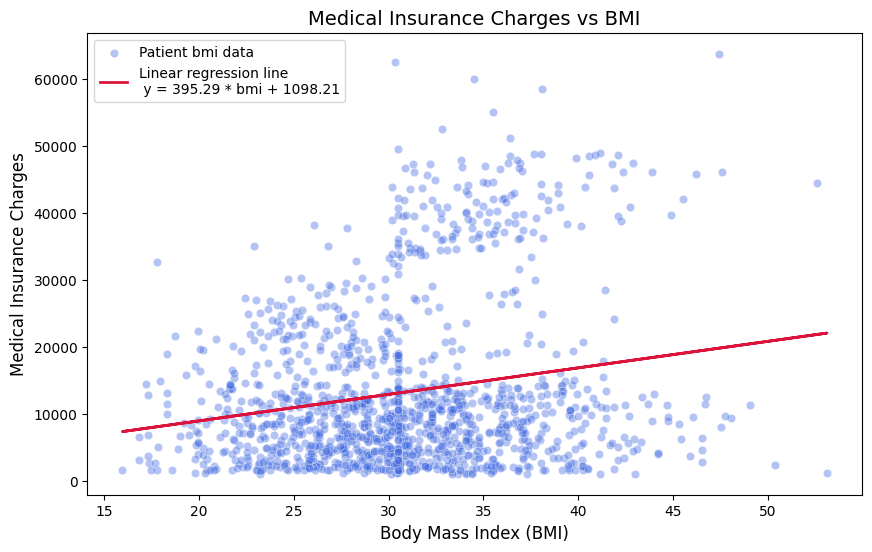

In [46]:
from matplotlib import pyplot as plt   
import seaborn as sns

plt.figure(figsize = (10,6))
sns.scatterplot(x = bmi_data, y = charges_data, alpha = 0.4,  color = "royalblue", label = "Patient bmi data")
linear_regression_line = b1 * bmi_data + b0
plt.plot(bmi_data, linear_regression_line, color="crimson", linewidth = 2, label = f"Linear regression line\n y = {b1:.2f} * bmi + {b0:.2f}")
plt.xlabel("Body Mass Index (BMI)", fontsize = 12)
plt.ylabel("Medical Insurance Charges", fontsize = 12)
plt.title("Medical Insurance Charges vs BMI", fontsize = 14)
plt.legend(fontsize = 10)
plt.show()